In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, i1, k0, k1
import CoolProp.CoolProp as CP
from scipy.interpolate import interp1d
from tabulate import tabulate
import pandas as pd
from IPython.display import display # Importamos display para Jupyter

# Intercambiador de calor a contraflujo sin aletas

In [30]:
class IntercambiadorContraflujo:

    '''Clase para modelar un intercambiador de calor de contraflujo.
    Se asumirá que el fluido caliente va por el tubo, y el frío por la sección anular'''

    def __init__(self, Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube):

        '''Recibe:
        Q_hot: Caudal volumétrico del fluido caliente (m^3/s)
        Q_cold: Caudal volumétrico del fluido frío (m^3/s)
        T_in_hot: Temperatura de entrada del fluido caliente (K)
        T_in_cold: Temperatura de entrada del fluido frío (K)
        D_in_hot: Diámetro interno del tubo del fluido caliente (m)
        D_out_hot: Diámetro externo del tubo del fluido caliente (m)
        D_in_cold: Diámetro interno del tubo del fluido frío (m)
        D_out_cold: Diámetro externo del tubo del fluido frío (m)
        Length: Longitud del intercambiador (m)
        k_tube: Conductividad térmica del material del tubo (W/m·K)'''

        self.Q_hot = Q_hot
        self.Q_cold = Q_cold
        self.T_in_hot = T_in_hot
        self.T_in_cold = T_in_cold
        self.D_in_hot = D_in_hot
        self.D_out_hot = D_out_hot
        self.D_in_cold = D_in_cold
        self.D_out_cold = D_out_cold
        self.Length = Length
        self.k_tube = k_tube
        self.P = 101325  # Presión atmosférica en Pa
        self.cold_fluid = 'Ethanol'

    def calcular_propiedades(self):
        self.rho_hot = CP.PropsSI('D', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.cp_hot = CP.PropsSI('C', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.mu_hot = CP.PropsSI('V', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.k_hot = CP.PropsSI('L', 'T', self.T_in_hot, 'P', self.P, 'Water')  
        self.beta_hot = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.nu_hot = self.mu_hot / self.rho_hot
        self.m_dot_hot = self.rho_hot * self.Q_hot
        self.Re_hot = (4 * self.m_dot_hot) / (np.pi * (self.D_in_hot) * self.mu_hot)
        self.Pr_hot = self.cp_hot * self.mu_hot / self.k_hot


        self.rho_cold = CP.PropsSI('D', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.cp_cold = CP.PropsSI('C', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.mu_cold = CP.PropsSI('V', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.k_cold = CP.PropsSI('L', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.beta_cold = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        self.nu_cold = self.mu_cold / self.rho_cold
        self.m_dot_cold = self.rho_cold * self.Q_cold
        self.Re_cold = (4 * self.m_dot_cold) / (np.pi * (self.D_in_cold + self.D_out_hot) * self.mu_cold)
        self.Pr_cold = self.cp_cold * self.mu_cold / self.k_cold
        self.D_h = self.D_in_cold - self.D_out_hot

        self.C_min = min(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_max = max(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_ratio = self.C_min / self.C_max

    def conveccion_tubo_interior(self):

        '''Calculamos el coeficiente de convección para el 
        fluido caliente, que va por el tubo interior.'''

        self.A_hot = np.pi * self.D_in_hot * self.Length

        if self.Re_hot < 2300:
            self.Nu_hot = 4.36
        else:
            self.Nu_hot = 0.023 * (self.Re_hot ** 0.8) * (self.Pr_hot ** 0.3)

        self.h_hot = self.Nu_hot * self.k_hot / self.D_in_hot

    def conveccion_seccion_anular(self):
        
        '''Calculamos el coeficiente de convección para el 
        fluido frío, que va por la sección anular.'''

        self.A_cold = np.pi * (self.D_out_hot * self.Length)

        self.tabla_8_3 = {
            "Di_Do": [0.05, 0.10, 0.20, 0.40, 0.60, 0.80],
            "Nu_ii": [17.81, 11.91, 8.499, 6.583, 5.912, 5.58],
            "Nu_oo": [4.792, 4.834, 4.833, 4.979, 5.099, 5.24]
        }

        Di_Do = self.D_out_hot / self.D_in_cold

        # Creamos las funciones de interpolación
        # 'kind=cubic' para curvas suaves o 'linear' para mayor seguridad con pocos datos
        interp_Nu_ii = interp1d(self.tabla_8_3["Di_Do"], self.tabla_8_3["Nu_ii"], kind='cubic', fill_value="extrapolate")
        # interp_Nu_oo = interp1d(self.tabla_8_3["Di_Do"], self.tabla_8_3["Nu_oo"], kind='cubic', fill_value="extrapolate")

        # Calculamos los Nusselt específicos para tu geometría
        self.Nu_ii_interp = float(interp_Nu_ii(Di_Do))
        # self.Nu_oo_interp = float(interp_Nu_oo(Di_Do))

        if self.Re_cold < 2300:
            factor_ajuste = 1.0
        else:
            factor_ajuste = 0.86 * ((self.D_out_hot / self.D_in_cold) ** (-0.16))

        self.h_cold = factor_ajuste * self.Nu_ii_interp * self.k_cold / self.D_h

    def calcular_UA(self):

        '''Calculamos el producto UA para cada fluido y el total.'''

        self.R_hot = 1 / (self.h_hot * self.A_hot)
        self.R_cold = 1 / (self.h_cold * self.A_cold)
        self.R_conduction = np.log(self.D_out_hot / self.D_in_hot) / (2 * np.pi * self.k_tube * self.Length)

        # Para intercambiadores en contraflujo, el UA total se calcula como:
        self.UA_total = 1 / (self.R_hot + self.R_cold + self.R_conduction)

    def calcular_efectividad(self):
        
        '''Calculamos la efectividad del intercambiador de calor.'''

        self.NTU = self.UA_total / self.C_min

        exp_term = np.exp(-self.NTU * (1 - self.C_ratio))

        if self.C_min == self.C_max:
            self.efectividad = self.NTU / (1 + self.NTU)
        else:
            self.efectividad = (1 - exp_term) / (1 - (self.C_ratio * exp_term))

    def calcular_temperaturas_salida(self):
        
        '''Calculamos las temperaturas de salida de ambos fluidos.'''

        self.Q_max = self.C_min * (self.T_in_hot - self.T_in_cold)
        self.Q_hx = self.efectividad * self.Q_max

        self.T_out_hot = self.T_in_hot - (self.Q_hx / (self.m_dot_hot * self.cp_hot))
        self.T_out_cold = self.T_in_cold + (self.Q_hx / (self.m_dot_cold * self.cp_cold))

    def grafico_intercambiador(self):
        
        '''Generamos un gráfico del intercambiador de calor.'''

        plt.figure(figsize=(10, 6))
        plt.plot([0, self.Length], [self.T_in_hot - 273.15, self.T_out_hot - 273.15], label='Agua', marker='o')
        plt.plot([0, self.Length], [self.T_in_cold - 273.15, self.T_out_cold - 273.15], label='Etanol', marker='o')
        plt.xlabel('Longitud del Intercambiador (m)')
        plt.ylabel('Temperatura (K)')
        plt.title('Perfil de Temperatura en el Intercambiador de Calor')
        plt.legend()
        plt.grid()
        plt.show()

    def resumen(self):

        '''Imprimimos un resumen de los resultados obtenidos.'''

        data = [
            ['T_in_hot (K)', self.T_in_hot - 273.15],
            ['T_out_hot (K)', self.T_out_hot - 273.15],
            ['T_in_cold (K)', self.T_in_cold - 273.15],
            ['T_out_cold (K)', self.T_out_cold - 273.15],
            ['Efectividad', self.efectividad],
            ['UA_total (W/K)', self.UA_total],
            ['Re_hot', self.Re_hot],
            ['Re_cold', self.Re_cold],
            ['h_hot (W/m^2K)', self.h_hot],
            ['h_cold (W/m^2K)', self.h_cold]
        ]
        headers = ['Parámetro', 'Valor']
        print(tabulate(data, headers=headers, tablefmt="grid"))

    def ejecutar(self):
        
        '''Ejecutamos todos los cálculos en orden.'''

        self.calcular_propiedades()
        self.conveccion_tubo_interior()
        self.conveccion_seccion_anular()
        self.calcular_UA()
        self.calcular_efectividad()
        self.calcular_temperaturas_salida()
        self.resumen()
        self.grafico_intercambiador()


Código de ejemplo

+-----------------+--------------+
| Parámetro       |        Valor |
+=================+==============+
| T_in_hot (K)    |   20         |
+-----------------+--------------+
| T_out_hot (K)   |   19.6326    |
+-----------------+--------------+
| T_in_cold (K)   |    4         |
+-----------------+--------------+
| T_out_cold (K)  |    4.05581   |
+-----------------+--------------+
| Efectividad     |    0.0229656 |
+-----------------+--------------+
| UA_total (W/K)  |    1.62009   |
+-----------------+--------------+
| Re_hot          | 3783.34      |
+-----------------+--------------+
| Re_cold         | 5346.31      |
+-----------------+--------------+
| h_hot (W/m^2K)  | 3213.66      |
+-----------------+--------------+
| h_cold (W/m^2K) |   83.6188    |
+-----------------+--------------+


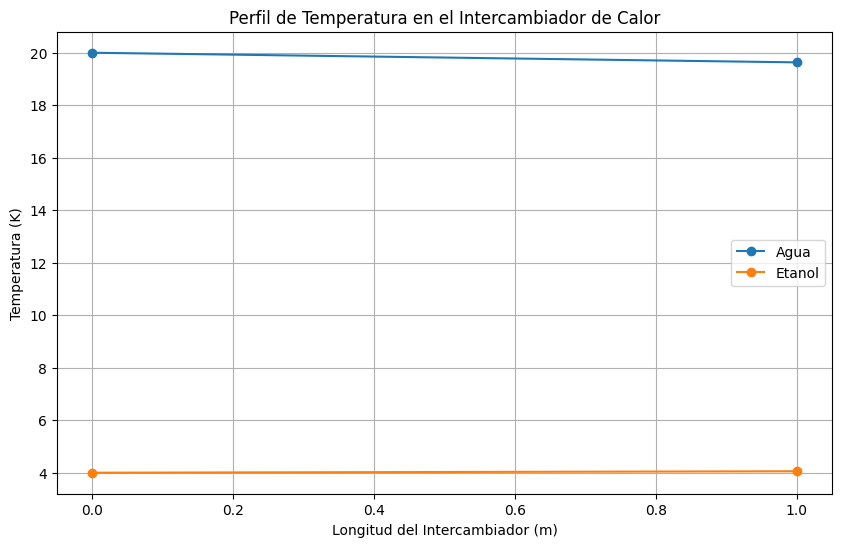

In [31]:
Q_hot = 1 * 0.001 / 60 # (pasamos de L/min a m³/s)
Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - 0.76) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
D_in_cold = 4 * D_in_hot  # Diámetro interno del tubo del fluido frío (m)
D_out_cold = 4 * D_out_hot  # Diámetro externo del tubo del fluido frío (m)
Length = 1 # Longitud del intercambiador (m)
k_tube = 390  # Conductividad térmica del material del tubo (W/m·K)

intercambiador = IntercambiadorContraflujo(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube)
intercambiador.ejecutar()


# Intercambiador de calor a contraflujo con aletas

In [32]:
class IntercambiadorContraflujoAletas(IntercambiadorContraflujo):
    '''Clase para modelar un intercambiador de calor de contraflujo con aletas.
    Se asume que el fluido caliente va por el tubo, y el frío por la sección anular.'''

    def __init__(self, Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, N_aletas, D_aleta, t_aleta):

        super().__init__(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube)
        self.N_aletas = N_aletas
        self.D_aleta = D_aleta
        self.t_aleta = t_aleta

    def calcular_geometria_aleta(self):
        self.r2 = self.D_aleta / 2
        self.r1 = self.D_out_hot / 2
        self.r2c = self.r2 + (self.t_aleta / 2)

    def calcular_efectividad_aleta(self):

        '''Calculamos la efectividad de una aleta'''

        self.m = np.sqrt((2 * self.h_cold) / (self.k_tube * self.t_aleta))
        K1_mr1 = k1(self.m * self.r1)
        I1_mr2c = i1(self.m * self.r2c)
        I1_mr1 = i1(self.m * self.r1)
        K1_mr2c = k1(self.m * self.r2c)
        I0_mr1 = i0(self.m * self.r1)
        K1_mr2c = k1(self.m * self.r2c)
        K0_mr1 = k0(self.m * self.r1)
        I1_mr2c = i1(self.m * self.r2c)

        numerador = (K1_mr1 * I1_mr2c) - (I1_mr1 * K1_mr2c)
        denominador = (I0_mr1 * K1_mr2c) + (K0_mr1 * I1_mr2c)

        C2 = (2*self.r1 / self.m) / ((self.r2c**2 - self.r1**2))

        self.eficiencia_aleta = C2 * (numerador / denominador)

    def calcular_eficiencia_total(self):
        
        '''Calculamos la efectividad total del intercambiador con aletas.'''

        self.A_f = 2 * np.pi * (self.r2c**2 - self.r1**2)

        self.A_t = (self.N_aletas * self.A_f) + (2 * np.pi * self.r1 * (self.Length - self.N_aletas * self.t_aleta))

        self.eficiencia_total = 1 - (((self.A_f * self.N_aletas)/ (self.A_t)) * (1 - self.eficiencia_aleta))

    def calcular_UA(self):

        '''Calculamos el producto UA para cada fluido y el total.'''

        self.R_hot = 1 / (self.h_hot * self.A_hot)
        self.R_cold = 1 / (self.eficiencia_total * self.h_cold * self.A_t)
        self.R_conduction = np.log(self.D_out_hot / self.D_in_hot) / (2 * np.pi * self.k_tube * self.Length)

        # Para intercambiadores en contraflujo, el UA total se calcula como:
        self.UA_total = 1 / (self.R_hot + self.R_cold + self.R_conduction)

    def calcular_largo_sin_aletas(self):
        
        '''Calculamos el largo efectivo del intercambiador sin considerar las aletas.'''

        self.Length_sin_aletas = self.Length - (self.N_aletas * self.t_aleta)

    def ejecutar(self):
        
        '''Ejecutamos todos los cálculos en orden.'''

        self.calcular_propiedades()
        self.conveccion_tubo_interior()
        self.conveccion_seccion_anular()
        self.calcular_geometria_aleta()
        self.calcular_efectividad_aleta()
        self.calcular_eficiencia_total()
        self.calcular_UA()
        self.calcular_efectividad()
        self.calcular_temperaturas_salida()
        self.calcular_largo_sin_aletas()
        # self.resumen()
        # self.grafico_intercambiador()  

Código de prueba:

In [33]:
Q_hot = 1 * 0.001 / 60 # (pasamos de L/min a m³/s)
Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = -3 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - 0.76) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
D_in_cold = 1.5 * D_in_hot  # Diámetro interno del tubo del fluido frío (m)
D_out_cold = 1.5 * D_out_hot  # Diámetro externo del tubo del fluido frío (m)
Length = 1 # Longitud del intercambiador (m)
k_tube = 390  # Conductividad térmica del material del tubo (W/m·K)
N_aletas = 10
D_aleta = 1.3 * D_out_hot # Diámetro de la aleta (m)
t_aleta = 5e-3 # Espesor de la aleta (m)
intercambiador_aletas = IntercambiadorContraflujoAletas(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, N_aletas, D_aleta, t_aleta)
intercambiador_aletas.ejecutar()

Ahora armaremos un gráfico de temperatura de salida del fluido caliente (agua) en función del número de aletas

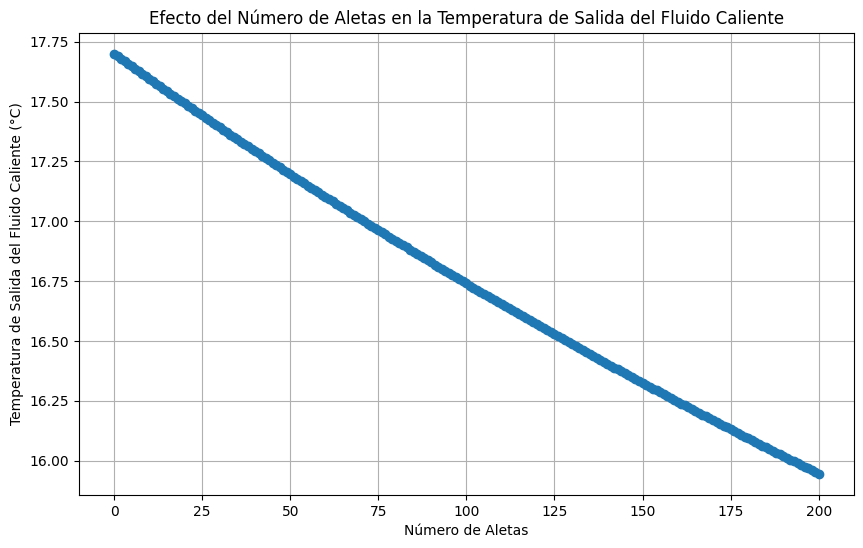

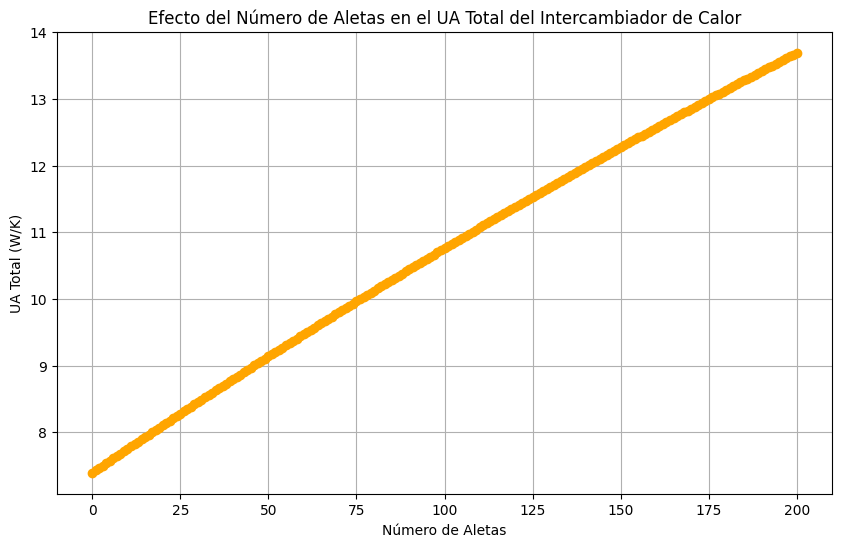

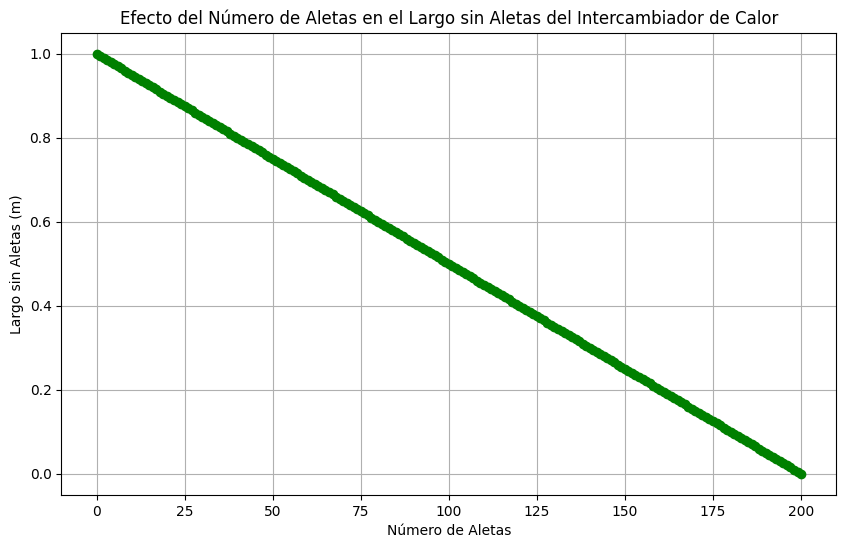

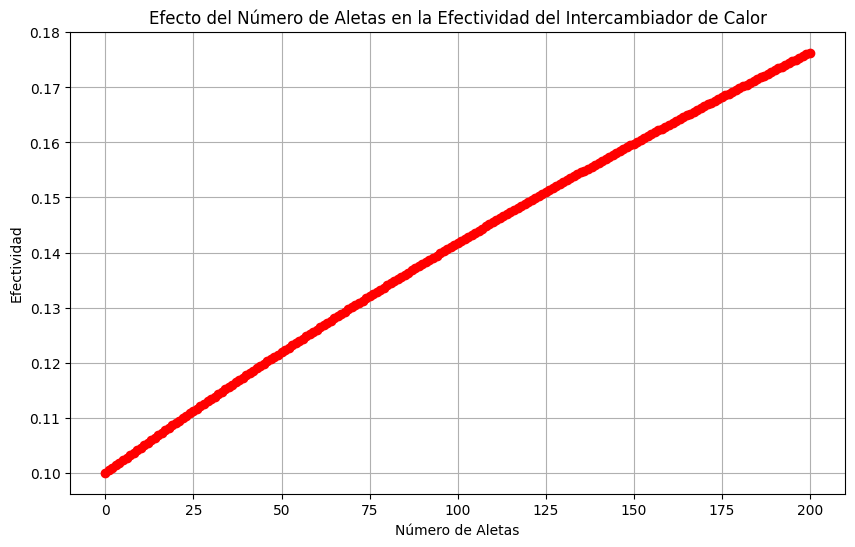

In [34]:
numero_aletas = np.arange(0, 201, 1)  # De 0 a 200 aletas
temperaturas_salida_hot = []
valores_UA = []
largo_sin_aletas = []
efectividades = []
for N in numero_aletas:
    intercambiador_aletas = IntercambiadorContraflujoAletas(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, N, D_aleta, t_aleta)
    intercambiador_aletas.ejecutar()
    temperaturas_salida_hot.append(intercambiador_aletas.T_out_hot - 273.15)
    largo_sin_aletas.append(intercambiador_aletas.Length_sin_aletas)
    valores_UA.append(intercambiador_aletas.UA_total)
    efectividades.append(intercambiador_aletas.efectividad)

# Gráfico de temperatura de salida del fluido caliente vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, temperaturas_salida_hot, marker='o')
plt.xlabel('Número de Aletas')
plt.ylabel('Temperatura de Salida del Fluido Caliente (°C)')
plt.title('Efecto del Número de Aletas en la Temperatura de Salida del Fluido Caliente')
plt.grid()
plt.show()

# Gráfico de UA total vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, valores_UA, marker='o', color='orange')
plt.xlabel('Número de Aletas')
plt.ylabel('UA Total (W/K)')
plt.title('Efecto del Número de Aletas en el UA Total del Intercambiador de Calor')
plt.grid()
plt.show()

# Gráfico del largo sin aletas vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, largo_sin_aletas, marker='o', color='green')
plt.xlabel('Número de Aletas')
plt.ylabel('Largo sin Aletas (m)')
plt.title('Efecto del Número de Aletas en el Largo sin Aletas del Intercambiador de Calor')
plt.grid()
plt.show()

# Gráfico de efectividad vs número de aletas
plt.figure(figsize=(10, 6))
plt.plot(numero_aletas, efectividades, marker='o', color='red')
plt.xlabel('Número de Aletas')
plt.ylabel('Efectividad')
plt.title('Efecto del Número de Aletas en la Efectividad del Intercambiador de Calor')
plt.grid()
plt.show()

# Optimicación para determinar la combinación que genera la menor temperatura posible

In [35]:
Q_hot = 1 * 0.001 / 60 # (pasamos de L/min a m³/s)
Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - (2*0.6)) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
Length = 1 # Longitud del intercambiador (m)
k_tube = 390  # Conductividad térmica del material del tubo (W/m·K)
t_aleta = 1e-3 # Espesor de la aleta (m)

# 1. Definición de los espacios de búsqueda
possible_fin_values = np.arange(0, 51, 1)  # De 0 a 50 aletas

# Diámetros comerciales de PVC
# https://catalogo.extension.cchc.cl/documentos/documentos/16094.pdf
possible_cold_inner_diameters = np.array([8, 10, 13.6, 17, 22, 27.2, 34, 42.6, 53.6]) * 1e-3
possible_cold_outer_diameters = np.array([10, 12, 16, 20, 25, 32, 40, 50, 63]) * 1e-3

# Definición de los posibles diámetros de la aleta
possible_fin_diameters = np.linspace(1.1, 1.9, 9) * D_out_hot # Diámetros de aleta basados en el diámetro externo del tubo caliente

results = []

for D_in_cold, D_out_cold in zip(possible_cold_inner_diameters, possible_cold_outer_diameters):
    for N_aletas in possible_fin_values:
        for D_aleta in possible_fin_diameters:
            
            intercambiador_aletas = IntercambiadorContraflujoAletas(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, N_aletas, D_aleta, t_aleta)
            intercambiador_aletas.ejecutar()

            results.append({
                'D_in_cold': D_in_cold,
                'D_out_cold': D_out_cold,
                'N_aletas': N_aletas,
                'D_aleta': D_aleta,
                'T_out_hot': intercambiador_aletas.T_out_hot - 273.15,
                'UA_total': intercambiador_aletas.UA_total,
                'Efectividad': intercambiador_aletas.efectividad
            })

# 3. Análisis con Pandas

# Forzar a Pandas a mostrar todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Convertimos la lista de diccionarios en un DataFrame
df_resultados = pd.DataFrame(results)

# Encontramos el índice de la fila con la menor temperatura de salida
indice_optimo = df_resultados['T_out_hot'].idxmin()
configuracion_optima = df_resultados.loc[indice_optimo]

# 4. Mostrar resultados
print("--- RESUMEN DE OPTIMIZACIÓN ---")
print(f"Total de configuraciones simuladas: {len(df_resultados)}")

print("\nCONFIGURACIÓN ÓPTIMA ENCONTRADA:")
# Al ser una sola fila (Serie), la convertimos a DataFrame con .to_frame() para que se vea bonita, y la transponemos con .T
display(configuracion_optima.to_frame().T)

print("\nTOP 5 MEJORES DISEÑOS:")
top_5 = df_resultados.sort_values(by='T_out_hot').head(5)
# display() renderiza la tabla completa en Jupyter Notebook
display(top_5)

# Guardamos el DataFrame completo en un archivo CSV para análisis posterior
df_resultados.to_csv('datos_experimentales/resultados_intercambiador_contraflujo_aletas.csv', index=False)

--- RESUMEN DE OPTIMIZACIÓN ---
Total de configuraciones simuladas: 4131

CONFIGURACIÓN ÓPTIMA ENCONTRADA:


,D_in_cold,D_out_cold,N_aletas,D_aleta,T_out_hot,UA_total,Efectividad
458,0.008,0.01,50.0,0.012065,17.522545,11.854226,0.154841



TOP 5 MEJORES DISEÑOS:


,D_in_cold,D_out_cold,N_aletas,D_aleta,T_out_hot,UA_total,Efectividad
458,0.008,0.01,50,0.012065,17.522545,11.854226,0.154841
449,0.008,0.01,49,0.012065,17.533867,11.794569,0.154133
440,0.008,0.01,48,0.012065,17.545228,11.734764,0.153423
431,0.008,0.01,47,0.012065,17.556628,11.674810,0.152711
422,0.008,0.01,46,0.012065,17.568067,11.614707,0.151996
